# 🧪 Router Unit Tests & Comprehensive Validation

This notebook validates all router functionality across **all 3 router types**:
- ✅ Initialization & loading
- ✅ Single routing & batch routing
- ✅ All 4 routing modes (accuracy, cheap, fast, balanced)
- ✅ Edge cases & error handling
- ✅ Determinism & reproducibility
- ✅ Cross-router comparison

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))  # artemis_final/
sys.path.insert(0, str(Path.cwd().parent.parent / 'router_train'))  # router_train/

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Config
# Detect best device
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f'🚀 Using CUDA: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('🍎 Using Apple MPS')
else:
    DEVICE = 'cpu'
    print('💻 Using CPU')
CHECKPOINTS_DIR = Path.cwd().parent.parent / 'checkpoints'  # artemis_final/checkpoints/

print('✓ Setup complete')
print(f'Device: {DEVICE}')
print(f'Checkpoints: {CHECKPOINTS_DIR}')

🍎 Using Apple MPS
✓ Setup complete
Device: mps
Checkpoints: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints


---
## 🔧 Load All Routers

In [3]:
from artemis_router.inference_classical_router import ClassicalRouterInference
from artemis_router.inference_pairwise_router import PairwiseRouterInference

In [4]:

# Dictionary to hold all routers
routers = {}

# Load Classical Router
print('Loading Classical Router...')
routers['classical'] = ClassicalRouterInference(
    str(CHECKPOINTS_DIR / 'best_classical_router.pt'), device=DEVICE, verbose=False
)
print('  ✓ Classical loaded')

# Load Pairwise Router
print('Loading Pairwise Router...')
routers['pairwise'] = PairwiseRouterInference(
    str(CHECKPOINTS_DIR / 'best_pairwise_router.pt'), device=DEVICE, verbose=False
)
print('  ✓ Pairwise loaded')

# Try to load Reward Router (may be corrupted)
print('Loading Reward Router...')
try:
    from artemis_router.inference_reward_router import RewardRouterInference
    routers['reward'] = RewardRouterInference(
        str(CHECKPOINTS_DIR / 'best_reward_router.pt'), device=DEVICE, verbose=False
    )
    print('  ✓ Reward loaded')
except Exception as e:
    print(f'  ⚠️ Reward router failed: {e}')
    print('  (Restore from backup to enable)')

print(f'\n📊 Loaded {len(routers)} router(s): {list(routers.keys())}')

Loading Classical Router...
  ✓ Classical loaded
Loading Pairwise Router...
  ✓ Pairwise loaded
Loading Reward Router...
  ✓ Reward loaded

📊 Loaded 3 router(s): ['classical', 'pairwise', 'reward']


---
## 🧪 Test 1: Basic Routing Validation

In [5]:
def run_test(test_name, test_fn):
    """Run a test and report results."""
    print(f'\n🧪 {test_name}')
    print('-' * 60)
    try:
        result = test_fn()
        print(f'✅ PASSED')
        return True, result
    except AssertionError as e:
        print(f'❌ FAILED: {e}')
        return False, None
    except Exception as e:
        print(f'💥 ERROR: {e}')
        return False, None

test_results = []

In [6]:
# Test 1: Basic routing works for all routers
def test_basic_routing():
    results = {}
    for name, router in routers.items():
        result = router.route(
            prompt='What is in this image?',
            mode='balanced',
            metadata={'router_task': 'vqa', 'source_dataset': 'test'}
        )
        
        assert 'chosen_model' in result, f'{name}: missing chosen_model'
        assert 'mode' in result, f'{name}: missing mode'
        assert 'inference_ms' in result, f'{name}: missing inference_ms'
        assert result['mode'] == 'balanced', f'{name}: wrong mode'
        
        results[name] = result
        print(f'  {name:12s} → {result["chosen_model"]:25s} ({result["inference_ms"]:.1f}ms)')
    
    return results

passed, result = run_test('Basic Routing', test_basic_routing)
test_results.append(('Basic Routing', passed))


🧪 Basic Routing
------------------------------------------------------------
  classical    → qwen2_5_vl_3b             (641.6ms)
  pairwise     → qwen2_5_vl_7b             (493.0ms)
  reward       → qwen3_vl_8b_thinking      (767.7ms)
✅ PASSED


In [7]:
# Test 2: All 4 modes work
def test_all_modes():
    modes = ['accuracy', 'cheap', 'fast', 'balanced']
    mode_results = {name: {} for name in routers}
    
    for mode in modes:
        print(f'  Mode: {mode}')
        for name, router in routers.items():
            result = router.route('Test prompt', mode=mode)
            assert result['mode'] == mode
            mode_results[name][mode] = result['chosen_model']
            print(f'    {name:12s} → {result["chosen_model"]}')
    
    return mode_results

passed, result = run_test('All Routing Modes', test_all_modes)
test_results.append(('All Modes', passed))


🧪 All Routing Modes
------------------------------------------------------------
  Mode: accuracy
    classical    → qwen2_5_vl_3b
    pairwise     → qwen2_5_vl_7b
    reward       → qwen3_vl_8b_thinking
  Mode: cheap
    classical    → qwen2_5_vl_3b
    pairwise     → qwen2_5_vl_7b
    reward       → qwen3_vl_8b_thinking
  Mode: fast
    classical    → qwen2_5_vl_3b
    pairwise     → qwen2_5_vl_7b
    reward       → qwen3_vl_8b_thinking
  Mode: balanced
    classical    → qwen2_5_vl_3b
    pairwise     → qwen2_5_vl_7b
    reward       → qwen3_vl_8b_thinking
✅ PASSED


In [8]:
# Test 3: Batch routing works
def test_batch_routing():
    prompts = [
        'What color is the sky?',
        'Extract text from document.',
        'Analyze this chart trend.',
    ]
    modes = ['cheap', 'fast', 'accuracy']
    
    for name, router in routers.items():
        results = router.route_batch(prompts, modes)
        assert len(results) == 3, f'{name}: wrong batch size'
        for i, r in enumerate(results):
            assert r['mode'] == modes[i], f'{name}: wrong mode at {i}'
        print(f'  {name:12s} → {[r["chosen_model"] for r in results]}')
    
    return True

passed, result = run_test('Batch Routing', test_batch_routing)
test_results.append(('Batch Routing', passed))


🧪 Batch Routing
------------------------------------------------------------
  classical    → ['qwen2_5_vl_3b', 'qwen2_5_vl_3b', 'qwen2_5_vl_3b']
  pairwise     → ['qwen2_5_vl_7b', 'qwen2_5_vl_7b', 'qwen2_5_vl_7b']
  reward       → ['qwen3_vl_8b_thinking', 'qwen3_vl_8b_thinking', 'qwen3_vl_8b_thinking']
✅ PASSED


In [9]:
# Test 4: Invalid mode raises error
def test_invalid_mode():
    for name, router in routers.items():
        try:
            router.route('test', mode='invalid_mode_xyz')
            assert False, f'{name}: should have raised error'
        except ValueError as e:
            print(f'  {name:12s} → Correctly raised ValueError')
    return True

passed, result = run_test('Invalid Mode Handling', test_invalid_mode)
test_results.append(('Invalid Mode', passed))


🧪 Invalid Mode Handling
------------------------------------------------------------
  classical    → Correctly raised ValueError
  pairwise     → Correctly raised ValueError
  reward       → Correctly raised ValueError
✅ PASSED


In [10]:
# Test 5: Determinism - same input gives same output
def test_determinism():
    prompt = 'Determinism test prompt'
    mode = 'balanced'
    
    for name, router in routers.items():
        r1 = router.route(prompt, mode=mode)
        r2 = router.route(prompt, mode=mode)
        r3 = router.route(prompt, mode=mode)
        
        assert r1['chosen_model'] == r2['chosen_model'] == r3['chosen_model'], \
            f'{name}: not deterministic'
        print(f'  {name:12s} → All 3 calls: {r1["chosen_model"]}')
    
    return True

passed, result = run_test('Determinism', test_determinism)
test_results.append(('Determinism', passed))


🧪 Determinism
------------------------------------------------------------
  classical    → All 3 calls: qwen2_5_vl_3b
  pairwise     → All 3 calls: qwen2_5_vl_7b
  reward       → All 3 calls: qwen3_vl_8b_thinking
✅ PASSED


In [11]:
# Test 6: get_stats returns expected info
def test_get_stats():
    required_keys = ['device', 'num_models', 'num_modes', 'model_names', 'mode_names']
    
    for name, router in routers.items():
        stats = router.get_stats()
        for key in required_keys:
            assert key in stats, f'{name}: missing {key}'
        
        print(f'  {name:12s} → {stats["num_models"]} models, {stats["num_modes"]} modes')
    
    return True

passed, result = run_test('Router Stats', test_get_stats)
test_results.append(('Stats', passed))


🧪 Router Stats
------------------------------------------------------------
  classical    → 5 models, 4 modes
  pairwise     → 5 models, 4 modes
  reward       → 5 models, 4 modes
✅ PASSED


---
## 📊 Test Summary

In [12]:
# Summary
print('\n' + '=' * 60)
print('📊 TEST SUMMARY')
print('=' * 60)

passed_count = sum(1 for _, p in test_results if p)
total_count = len(test_results)

for test_name, passed in test_results:
    status = '✅' if passed else '❌'
    print(f'{status} {test_name}')

print(f'\nTotal: {passed_count}/{total_count} tests passed')

if passed_count == total_count:
    print('\n🎉 ALL TESTS PASSED!')
else:
    print(f'\n⚠️ {total_count - passed_count} test(s) failed')


📊 TEST SUMMARY
✅ Basic Routing
✅ All Modes
✅ Batch Routing
✅ Invalid Mode
✅ Determinism
✅ Stats

Total: 6/6 tests passed

🎉 ALL TESTS PASSED!


---
## 🔬 Detailed Output Analysis

In [13]:
# Run comprehensive analysis on multiple prompts
analysis_prompts = [
    ('What is the capital of France?', 'qa'),
    ('Extract all text from this document.', 'ocr'),
    ('Analyze the trend in this bar chart.', 'chartqa'),
    ('Explain this scientific diagram.', 'diagram_reasoning'),
    ('What color is the cat in the image?', 'vqa'),
    ('Solve this math problem shown.', 'math'),
    ('Describe the scene in detail.', 'description'),
    ('Is this image real or AI-generated?', 'classification'),
]

all_results = []

for prompt, task in analysis_prompts:
    for mode in ['accuracy', 'cheap', 'fast', 'balanced']:
        for router_name, router in routers.items():
            result = router.route(
                prompt=prompt,
                mode=mode,
                metadata={'router_task': task, 'source_dataset': 'test'}
            )
            all_results.append({
                'prompt': prompt[:30] + '...',
                'task': task,
                'mode': mode,
                'router': router_name,
                'chosen_model': result['chosen_model'],
                'latency_ms': result['inference_ms'],
            })

df_results = pd.DataFrame(all_results)
print(f'Generated {len(df_results)} routing decisions')
df_results.head(10)

Generated 96 routing decisions


,prompt,task,mode,router,chosen_model,latency_ms
0,What is the capital of France?...,qa,accuracy,classical,gemma_3_27b,15.141964
1,What is the capital of France?...,qa,accuracy,pairwise,qwen2_5_vl_7b,14.411926
2,What is the capital of France?...,qa,accuracy,reward,qwen3_vl_8b_thinking,11.862993
3,What is the capital of France?...,qa,cheap,classical,gemma_3_27b,3.607988
4,What is the capital of France?...,qa,cheap,pairwise,qwen2_5_vl_7b,4.026175
5,What is the capital of France?...,qa,cheap,reward,qwen3_vl_8b_thinking,10.950804
6,What is the capital of France?...,qa,fast,classical,qwen2_5_vl_3b,3.208876
7,What is the capital of France?...,qa,fast,pairwise,qwen2_5_vl_7b,3.816843
8,What is the capital of France?...,qa,fast,reward,qwen3_vl_8b_thinking,10.321140
9,What is the capital of France?...,qa,balanced,classical,gemma_3_27b,3.343105


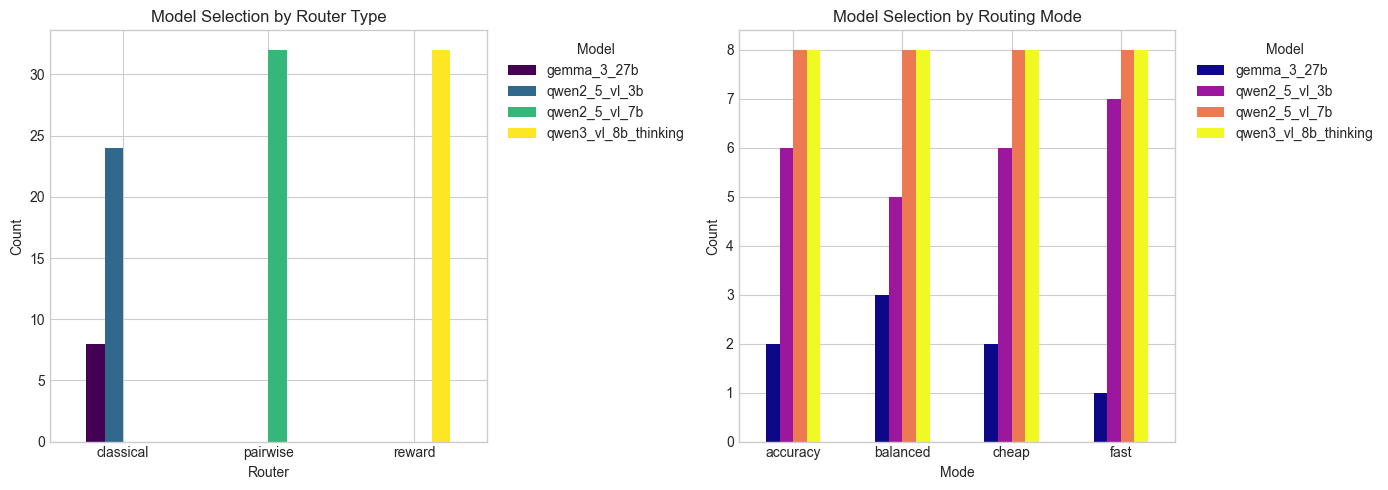

In [14]:
# Visualize model selection patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By router
ax1 = axes[0]
pivot1 = df_results.groupby(['router', 'chosen_model']).size().unstack(fill_value=0)
pivot1.plot(kind='bar', ax=ax1, colormap='viridis')
ax1.set_title('Model Selection by Router Type')
ax1.set_xlabel('Router')
ax1.set_ylabel('Count')
ax1.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=0)

# By mode
ax2 = axes[1]
pivot2 = df_results.groupby(['mode', 'chosen_model']).size().unstack(fill_value=0)
pivot2.plot(kind='bar', ax=ax2, colormap='plasma')
ax2.set_title('Model Selection by Routing Mode')
ax2.set_xlabel('Mode')
ax2.set_ylabel('Count')
ax2.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()